In [35]:
import pandas as pd

###`Q-1:` You are given a Multi index DataFrame. You task is to swap level-0 index with level-0 column.
* Change Branch -> ('cse', 'ece') as columns at level-0 and ('delhi'	'mumbai') as level-0 Index
* And Sort on row index level-0

In [36]:
# Given Code Snippets
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
df = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

df

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [37]:
df.stack(level=0).unstack(level=0).swaplevel(axis=1).sort_index(axis=1, level=0).swaplevel(axis=0).sort_index(level=0)

/tmp/ipykernel_888/2564566324.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df.stack(level=0).unstack(level=0).swaplevel(axis=1).sort_index(axis=1, level=0).swaplevel(axis=0).sort_index(level=0)


cse                  ece         
            avg_package students avg_package students
delhi  2019           1        2           9       10
       2020           3        4          11       12
       2021           5        6          13       14
       2022           7        8          15       16
mumbai 2019           0        0           0        0
       2020           0        0           0        0
       2021           0        0           0        0
       2022           0        0           0        0

###`Q-2:` Covid Cases Data Set Problem
 Make a DataFrame Using both Covid Dataset. With Country name as Level-0 and Provinance/State as Level-1 Index and date, No of cases and No of Deaths as Columns.

In [40]:
confirm = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTmqT3kxd0i0RUFiEnwA1Hboiunv28MeNTatZsIEqlPPB7mHrl0ttJL7utZ23_1s5FW8ZjODmB8jHIi/pub?gid=2142019845&single=true&output=csv')
deaths = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQn4nLCKIVZMw4e89YeRqgKaSAAwRFaZ6ILMW_FUejZ2tkv3Np1f9gD4QOl3ASHeLzWjOjfmLDKcCOF/pub?gid=212966958&single=true&output=csv")

In [41]:
confirm['Province/State'] = confirm['Province/State'].fillna('None')

In [42]:
deaths['Province/State'] = deaths['Province/State'].fillna('None')

In [43]:
confirm_long = confirm.melt(
    id_vars=['Province/State', 'Country/Region'],
    value_vars=confirm.columns[4:],
    var_name='Date',
    value_name='No of Cases'
)
confirm_long.head(2)

,Province/State,Country/Region,Date,No of Cases
0,None,Afghanistan,1/22/20,0
1,None,Albania,1/22/20,0


In [44]:
death_long = deaths.melt(
    id_vars=['Province/State', 'Country/Region'],
    value_vars=deaths.columns[4:],
    var_name='Date',
    value_name='No of Deaths'
)
death_long.head(2)

,Province/State,Country/Region,Date,No of Deaths
0,None,Afghanistan,1/22/20,0
1,None,Albania,1/22/20,0


In [45]:
covid = (
    confirm
    .melt(
        id_vars=['Province/State', 'Country/Region'],
        value_vars=confirm.columns[4:],
        var_name='Date',
        value_name='No of Cases'
    )
    .merge(
        deaths.melt(
            id_vars=['Province/State', 'Country/Region'],
            value_vars=deaths.columns[4:],
            var_name='Date',
            value_name='No of Deaths'
        ),
        on=['Province/State', 'Country/Region', 'Date']
    )
    .set_index(['Country/Region', 'Province/State'])
)

covid

,,Date,No of Cases,No of Deaths
Country/Region,Province/State,,,
Afghanistan,None,1/22/20,0,0
Albania,None,1/22/20,0,0
Algeria,None,1/22/20,0,0
Andorra,None,1/22/20,0,0
Angola,None,1/22/20,0,0
...,...,...,...,...
West Bank and Gaza,None,1/2/23,703228,5708
Winter Olympics 2022,None,1/2/23,535,0
Yemen,None,1/2/23,11945,2159


###`Q-3:` Show Country with Heighest death percent out of confirmed Cases.

In [46]:
covid_reset = covid.reset_index().groupby('Country/Region')

cases_df = covid_reset['No of Cases'].sum()
deaths_df = covid_reset['No of Deaths'].sum()

result_df = (deaths_df / cases_df) * 100
result_df.sort_values(ascending=False)

,0
Country/Region,
"Korea, North",600.000000
MS Zaandam,22.202624
Yemen,19.361718
Sudan,7.360250
Peru,7.092370
...,...
Antarctica,0.000000
Holy See,0.000000
Summer Olympics 2020,0.000000


### `Q-4` : Make a dataframe for India from Covid Data with one extra column representing no of new cases.

* Just for Assumption "No of new cases" will be equal to difference of "no of cases" with previous day.
* First day new cases will be NaN or equal to no of cases

Say on 12/30/22 No of cases is - 44679608	and a day previous (12/29/22) no of cases is - 44679382.

Then for 12/30/22 -> No of New Cases  = 44679608 - 44679382 =

Note:- Try using shift Function

Try using the shift function

```
s = pd.Series([1,2,3,4,5,6])
s #-> [1,2,3,4,5,6]
s.shift(1) #-> [NaN, 1,2,3,4,5]
s.shift(-1) #-> [2,3,4,5,6, NaN]
```

In [47]:
confirm_long = confirm.melt(
    id_vars=['Province/State', 'Country/Region'],
    value_vars=confirm.columns[4:],
    var_name='Date',
    value_name='No of Cases'
)

death_long = deaths.melt(
    id_vars=['Province/State', 'Country/Region'],
    value_vars=deaths.columns[4:],
    var_name='Date',
    value_name='No of Deaths'
)

print(confirm_long[confirm_long['Country/Region'] == 'India'].shape)
print(death_long[death_long['Country/Region'] == 'India'].shape)

(1077, 4)
(1077, 4)


In [48]:
covid = confirm_long.merge(
    death_long,
    on=['Province/State', 'Country/Region', 'Date']
)

print(covid[covid['Country/Region'] == 'India'].shape)

(1077, 5)


In [49]:
india = covid[covid['Country/Region'] == 'India']
india


,Province/State,Country/Region,Date,No of Cases,No of Deaths
148,None,India,1/22/20,0,0
437,None,India,1/23/20,0,0
726,None,India,1/24/20,0,0
1015,None,India,1/25/20,0,0
1304,None,India,1/26/20,0,0
...,...,...,...,...,...
309956,None,India,12/29/22,44679382,530699
310245,None,India,12/30/22,44679608,530702
310534,None,India,12/31/22,44679873,530705
310823,None,India,1/1/23,44680046,530707


In [50]:
india['Date'] = pd.to_datetime(india['Date'])
india = india.sort_values(by='Date')
india['No of New Cases'] = (
    india['No of Cases']
    - india['No of Cases'].shift(1)
)


/tmp/ipykernel_888/2612026234.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  india['Date'] = pd.to_datetime(india['Date'])
/tmp/ipykernel_888/2612026234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india['Date'] = pd.to_datetime(india['Date'])


In [51]:
india

,Province/State,Country/Region,Date,No of Cases,No of Deaths,No of New Cases
148,None,India,2020-01-22,0,0,NaN
437,None,India,2020-01-23,0,0,0.0
726,None,India,2020-01-24,0,0,0.0
1015,None,India,2020-01-25,0,0,0.0
1304,None,India,2020-01-26,0,0,0.0
...,...,...,...,...,...,...
309956,None,India,2022-12-29,44679382,530699,243.0
310245,None,India,2022-12-30,44679608,530702,226.0
310534,None,India,2022-12-31,44679873,530705,265.0
310823,None,India,2023-01-01,44680046,530707,173.0


### `Q-5:` Read the Dataset using the below given link and create a multi-index dataframe using the columns "Country" and "City/Town".

This dataset is about the most polluted cities in the world. You can get details from [here](https://www.kaggle.com/datasets/rajkumarpandey02/worlds-most-air-polluted-countries-cities).

**Dataset link:** https://tinyurl.com/2fe6vz4u Directly use this link to read.

**Task:**
1. Find out the name of the city of India which is most poluted based on PM10.
2. Find out the name of the city of India which has minumum pollution level based on PM10.
3. Do same operations (like 1 and 2) with the country China.
4. Make a pie chart based on the column "PM10" of the country Poland.
5. Make a bar chart based on the columns "PM2.5" and "PM10" of the countries Israel and Qatar.
6. Convert this MultiIndex DataFrame to Series by retaining the informations.

In [52]:
cities = pd.read_csv('/content/List of most-polluted cities by particulate matter concentration - List of most-polluted cities by particulate matter concentration.csv')

In [53]:
cities.set_index(['Country','City/Town'])

Unnamed: 0  Position  Year  PM2.5 Temporal coverage  \
Country     City/Town                                                           
India       Kanpur                 0         1  2016    173              >75%   
            Faridabad              1         2  2016    172              >75%   
            Gaya                   2         3  2016    149        50% -< 75%   
            Varanasi               3         4  2016    146              >75%   
            Patna                  4         5  2016    144              >75%   
...                              ...       ...   ...    ...               ...   
Poland      Lublin               495       496  2016     27              >75%   
            Siedlce              496       497  2016     27              >75%   
            Trzebinia            497       498  2016     27              >75%   
El Salvador San Salvador         498       499  2016     27        50% -< 75%   
Turkey      Sivas                499       500  2016     27              >75%   

                          PM10 Temporal coverage.1  Database version (year)  
Country     City/Town                                                        
India       Kanpur         319                 NaN                     2018  
            Faridabad      316                 NaN                     2018  
            Gaya           275                 NaN                     2018  
            Varanasi       260                 NaN                     2018  
            Patna          266                 NaN                     2018  
...                        ...                 ...                      ...  
Poland      Lublin          31                >75%                     2018  
            Siedlce         29                >75%                     2018  
            Trzebinia       35                >75%                     2018  
El Salvador San Salvador    59                 NaN                     2018  
Turkey      Sivas           56                >75%                     2018  

[500 rows x 8 columns]

In [60]:
# Q1.
temp_df = cities[cities['Country'] == 'India'].sort_values(by='PM10', ascending=False)
temp_df[['Country','City/Town','PM10']].head(10).set_index(['Country','City/Town'])

PM10
Country City/Town        
India   Kanpur        319
        Faridabad     316
        Delhi         292
        Gaya          275
        Patna         266
        Varanasi      260
        Lucknow       255
        Muzaffarpur   221
        Agra          194
        Jaipur        193

In [58]:
# Q2.
min_pollution = cities[cities['Country'] == 'India'].sort_values(by='PM10').head(1)
min_pollution[['Country','City/Town','PM10']]

,Country,City/Town,PM10
483,India,Aizawl,44


In [61]:
# Q3.
china_df = cities[cities['Country'] == 'China'].sort_values(by='PM10', ascending=False)
china_df[['Country','City/Town','PM10']].head(10).set_index(['Country','City/Town'])


PM10
Country City/Town         
China   Jinan          192
        Xingtai        186
        Handan         175
        Linfen         158
        Anyang         155
        Liaocheng      151
        Xianyang       149
        Shijiazhuang   147
        Baoding        147
        Cangzhou       147

In [62]:
# Q3.
min_pollution = cities[cities['Country'] == 'China'].sort_values(by='PM10').head(1)
min_pollution[['Country','City/Town','PM10']]

,Country,City/Town,PM10
476,China,Anshun,38


<Axes: ylabel='PM10'>

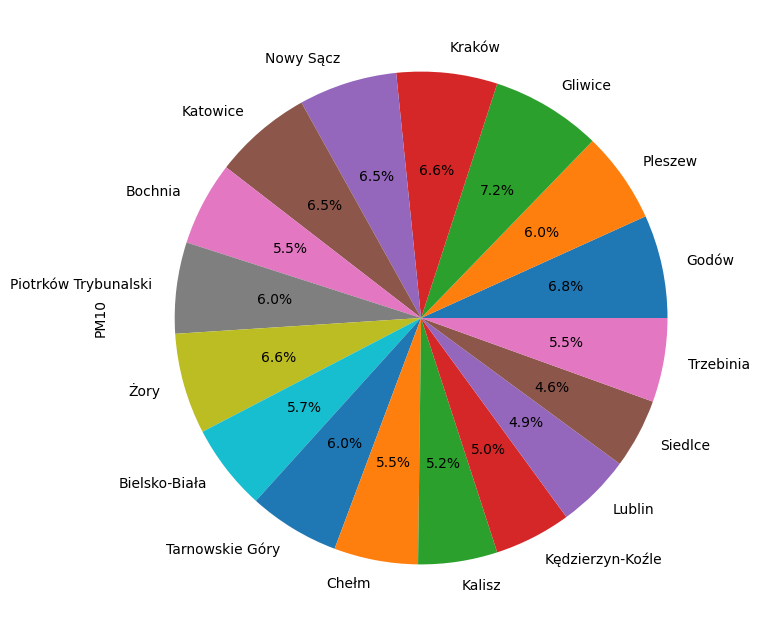

In [70]:
# Q4.
cities[cities['Country'] == 'Poland'].set_index(['City/Town'])['PM10'].plot(kind='pie',autopct='%1.1f%%',figsize=(8, 8))

<Axes: xlabel='Country,City/Town'>

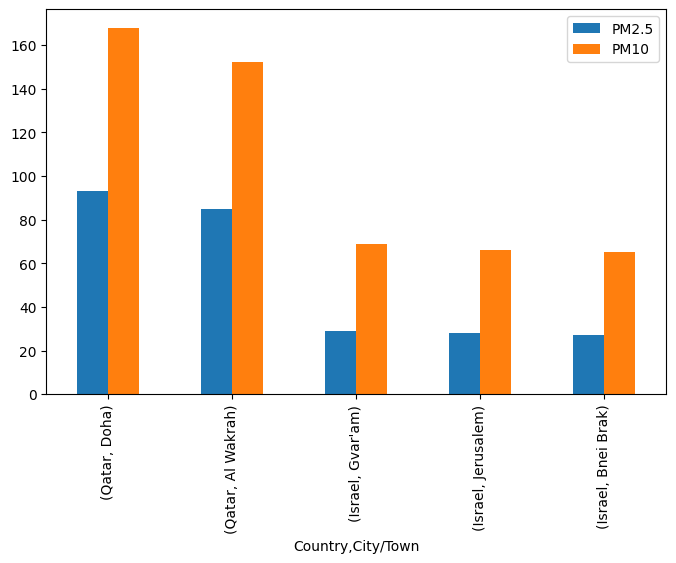

In [90]:
# Q5.
cities[cities['Country'].isin(['Israel','Qatar'])].set_index(['Country', 'City/Town'])[['PM2.5','PM10']].plot(kind='bar',figsize=(8, 5))